In [1]:
%load_ext autoreload
%autoreload 1

In [3]:
import os
import pandas as pd
import numpy as np
import scipy
from scipy.stats import spearmanr

import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib import rc
import seaborn as sns
import Bio.PDB
from scipy import stats
from Bio.PDB import SASA # SASA module won't load from newest version of Biopython for some reason
# import Geometry # Biopython Geometry module still not on main branch

import time
import sys
import glob
sys.path.append('/data/mhoffert/fiererlab/adenylate_kinase_ogt/protein_utils/')
from collections import Counter

# import Geometry

from IPython.display import display, clear_output

# Preprocessing steps

## New:
See README.md

## Old

Files are now unpacked with a bash script. A parallelized version of the python code calculates contact density and Rosetta is run in a parallelized bash script. see the wiki for details.

```
parallel -j 12 './unpack_structures.sh {}' :::: inds_unpack.txt
```
```
parallel -j 12 './run_rosetta.sh {}' :::: inds_rosetta.txt
```

## Compiling data
1. (May 2026) H-bonds list from Dru
2. (May 2026) Lid type
3. (May 2026) Per-residue SASA computed with freeSASA
4. (May 2026) Per-residue Buried SASA computed with freeSASA / Tien method
5. (May 2026) Per-residue Buried SASA computed with Rosetta
6. (May 2026) Structural metrics from Rosetta

Removing energy terms from the Rosetta function

### Arranging temp data for plotting

In [3]:
genome2temp = pd.read_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/metric_tables/renamed_files.txt', sep='\t', header=None)
genome2temp = genome2temp.dropna().apply(lambda row: pd.Series(index=['temp', 'genome'],
                                       data=[row[0].split('_bit')[0].split('_temp_')[-1],
                                            row[1].split('/')[-1].split('_closed')[0]]), axis=1)

In [4]:
genome2temp = genome2temp.set_index('genome')['temp']

### Load python-based SASA metrics

In [48]:
python_metrics_df = pd.read_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/metric_tables/20240325_python_metrics.tsv.gz', sep='\t', compression='gzip')
python_metrics_df = python_metrics_df.drop('Position', axis=1).rename(columns={'Contacts at 4.5 Å	':'contacts_4.5_bio', 'SASA':'total_sasa_bio'})
python_metrics_df.head()

,Contacts at 4.5 Å,total_sasa_bio,uid
0,11.358289,52.616491,GB_GCA_000376885.1
1,11.125581,49.464040,GB_GCA_000016765.1
2,11.289720,49.538232,GB_GCA_000242235.1
3,11.276190,50.018080,GB_GCA_000283575.1
4,11.359116,51.483049,GB_GCA_001054945.1


### Compile Rosetta data

In [20]:
# combine rosetta data
# old:
# rosetta_files = glob.glob('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/rosetta_out/*_processed_rosetta_out.sc')
rosetta_files = glob.glob('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/rosetta_out/*_A_processed_*.sc')
print(f'Found {len(rosetta_files)} files')

Found 9341 files


In [24]:
rosetta_data = []
for i, r in enumerate(rosetta_files):
    if i % 100 == 0:
        display(i)
        clear_output(wait=True)
    rosetta_data.append(pd.read_csv(r, delim_whitespace=True, skiprows=1, index_col='description'))

9300

In [25]:
rosetta_df = pd.concat(rosetta_data)
rosetta_df.head()

,SCORE:,total_score,avg_deg_4_5,avg_deg_8,avg_sc_nbrs_res_summary,bb_internal_hbonds,bbsc_internal_hbonds,calc_bsa_apolar,calc_bsa_total,cav_vol,...,packstat,polar_sasa,pro_close,rama_prepro,ref,sasa,sc_internal_hbonds,total_cc_contacts,yhh_planarity,secondary_structure
description,,,,,,,,,,,,,,,,,,,,,
GB_GCA_000016765.1_A_processed_0001,SCORE:,-450.126,1.316,10.730,2.697,132.0,30.0,14693.068,32220.639,185.593,...,0.631,4147.046,13.362,-17.049,82.279,10462.361,34.0,599.0,0.034,LEEEEELLLLLLHHHHHHHHHHHHLLEEEEHHHHHHHHHHLLLHHH...
GB_GCA_000016765.1_A_processed_0001,SCORE:,-450.126,1.316,10.730,2.697,132.0,30.0,14693.068,32220.639,121.605,...,0.638,4147.046,13.362,-17.049,82.279,10462.361,34.0,599.0,0.034,LEEEEELLLLLLHHHHHHHHHHHHLLEEEEHHHHHHHHHHLLLHHH...
GB_GCA_001187505.1_A_processed_0001,SCORE:,-443.850,1.298,10.757,2.727,117.0,22.0,12739.057,27251.518,221.106,...,0.576,4151.519,11.423,-10.415,35.368,9294.481,25.0,564.0,0.076,LEEEEELLLLLLHHHHHHHHHHHHLLLEEEHHHHHHHHHHLLLHHH...
GB_GCA_001054945.1_A_processed_0001,SCORE:,-431.800,1.243,10.768,2.669,117.0,20.0,12657.535,27124.416,303.025,...,0.589,4315.683,9.625,-13.340,28.665,9214.585,31.0,532.0,0.053,LEEEEELLLLLLHHHHHHHHHHHHLLLEEEHHHHHHHHHHLLLHHH...
GB_GCA_000717275.1_A_processed_0001,SCORE:,-421.557,1.287,10.890,2.767,119.0,25.0,13298.906,27195.635,186.818,...,0.639,3733.916,19.310,-15.942,62.870,8920.365,22.0,551.0,0.042,LEEEEELLLLLLHHHHHHHHHHHHLLLEEEHHHHHHHHHHLLLHHH...


In [26]:
# parse rosetta outputs
rosetta_df['genome_id'] = ['_'.join(s.split('_adk')[0].split('_A_pro')[0].split('_')[-3:]) for s in rosetta_df.index] #rosetta_df.index.map(lambda x: x.partition('.')[0])

# make a secondary structure series
secondary_structure = rosetta_df.groupby('genome_id').first()['secondary_structure']

# add rosetta metrics
rosetta_df['%S'] = rosetta_df['secondary_structure'].map(lambda x: x.count('E') / len(x))
rosetta_df['%L'] = rosetta_df['secondary_structure'].map(lambda x: x.count('L') / len(x))
rosetta_df['%H'] = rosetta_df['secondary_structure'].map(lambda x: x.count('H') / len(x))
rosetta_df['length'] = rosetta_df['secondary_structure'].map(len)
rosetta_df['avg_cc_contacts_per_res'] = rosetta_df['total_cc_contacts'] / rosetta_df['length']
rosetta_df = rosetta_df.groupby('genome_id').mean(numeric_only=True)

In [28]:
rosetta_df.to_csv('./../data/metric_tables/20260513_rosetta_metrics.tsv.gz', sep='\t', compression='gzip')

### Lid type 

#### Assigning lid type

In [47]:
# algorithm which examines the lid
print('loading alignment...')
with open('./../data/high_qual_alignments/backbone.filtered_only.afa', 'r') as handle:
    lines = [pd.Series(index=range(len(r.seq)), data=[i for i in str(r.seq)], name=r.id) for r in SeqIO.parse(handle, 'fasta')]

filtered_aln_df = pd.concat(lines, axis=1).T
print(f'This alignment contains {filtered_aln_df.shape[0]} sequences')
filtered_aln_df.head()

loading alignment...
This alignment contains 8532 sequences


,0,1,2,3,4,5,6,7,8,9,...,204,205,206,207,208,209,210,211,212,213
CP000699.1_1354|GB_GCA_000016765.1|adk|temp=30.0|bitscore=175.3,M,N,I,I,L,L,G,P,P,G,...,A,A,I,A,A,I,L,D,N,-
JH590862.1_220|GB_GCA_000242235.1|adk|temp=37.0|bitscore=192.2,V,K,I,V,M,L,G,A,P,G,...,E,A,I,K,A,L,L,-,-,-
AP012044.1_910|GB_GCA_000283575.1|adk|temp=30.0|bitscore=168.7,M,R,L,I,L,L,G,A,P,G,...,Q,A,I,L,H,A,L,G,R,-
AQXR01000011.1_67|GB_GCA_000376885.1|adk|temp=37.0|bitscore=178.2,M,R,L,L,I,M,G,P,Q,G,...,K,N,I,V,S,E,L,T,K,-
KE150266.1_745|GB_GCA_000411155.1|adk|temp=37.0|bitscore=164.5,P,A,I,L,I,L,G,A,P,G,...,E,R,I,R,Q,V,L,T,E,Y


#### Notes on lid annotation:
Pre-determined the approximate location of the lid domain with JalView: sites 128-158: picked a span between two highly conserved residues  

ADK isoforms assigned to three types:  
* lidded -> 1) h-bond or 2) zinc
* lidless -> 3) no lid
  
Again, used Jalview to identify 4C zinc domain (CCCC) or H-bond domain (HSDT) occurs at sites (130, 133, 149, 152)  

see: "ADK isoform assignment" section of Methods here: https://www.science.org/doi/10.1126/science.adu1058


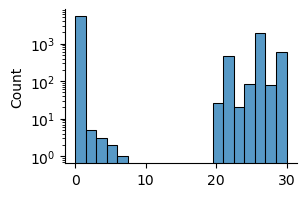

In [58]:
# quick plots to develop lid type code

# plot number of gap in lid: should be clear threshold for "lidless"
fig, ax =plt.subplots(figsize=(3,2))
sns.histplot(filtered_aln_df.loc[:, 128:158].eq('-').sum(1), bins=20)
sns.despine()
ax.set_yscale('log')

Gap count in lid is 15

In [78]:
# rules for assigning types:
def assign_lidded(row):
    if row.loc[128:158].eq('-').sum() >= 15:
        return True
    else:
        return False

def assign_zinc(row):
    if all(row.loc[i] == 'C' for i in [129, 132, 148, 151]):
        return True
    else:
        return False

def assign_hbond(row):
    residues = ['H', 'S', 'D', 'T']
    locs = [129, 132, 148, 151]
    if all(row.loc[locs[i]] == residues[i] for i in range(4)):
        return True
    else:
        return False
    

In [101]:
lidded_annot = filtered_aln_df.apply(lambda row: assign_lidded(row), axis=1)
zinc_annot = filtered_aln_df.apply(lambda row: assign_zinc(row), axis=1)
hbond_annot = filtered_aln_df.apply(lambda row: assign_hbond(row), axis=1)
    

In [102]:
filtered_aln_df.apply(lambda row: assign_zinc(row), axis=1).sum()

2575

In [108]:
lid_annotations = pd.concat([lidded_annot, zinc_annot, hbond_annot],
          keys=['lidded', 'zinc', 'hbond'], 
          axis=1)
print(lid_annotations.shape)

(8532, 3)


In [109]:
lid_annotations.to_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/metric_tables/20260501_lid_types.csv')

In [113]:
lid_annotations = pd.read_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/metric_tables/20260501_lid_types.csv', index_col=0)
lid_annotations['uid'] = [i.split('|')[1] for i in lid_annotations.index]
lid_annotations.head()

,lidded,zinc,hbond,uid
CP000699.1_1354|GB_GCA_000016765.1|adk|temp=30.0|bitscore=175.3,False,True,False,GB_GCA_000016765.1
JH590862.1_220|GB_GCA_000242235.1|adk|temp=37.0|bitscore=192.2,False,True,False,GB_GCA_000242235.1
AP012044.1_910|GB_GCA_000283575.1|adk|temp=30.0|bitscore=168.7,False,True,False,GB_GCA_000283575.1
AQXR01000011.1_67|GB_GCA_000376885.1|adk|temp=37.0|bitscore=178.2,True,False,False,GB_GCA_000376885.1
KE150266.1_745|GB_GCA_000411155.1|adk|temp=37.0|bitscore=164.5,True,False,False,GB_GCA_000411155.1


### Load freeSASA / pyrosetta-based SASA

In [33]:
sasas = pd.read_csv('./../data/metric_tables/20260513_sasa_metrics.tsv.gz',
                   sep='\t', compression='gzip',index_col=0)

In [34]:
sasas['uid'] = sasas['pdb'].apply(lambda x: x.split('/')[-1].split('_A')[0])

In [56]:
# add tien esimates of delta SASA
Tien_ASAs = {
    'ALA': 121.0,
    'ARG': 265.0,
    'ASN': 187.0,
    'ASP': 187.0,
    'CYS': 148.0,
    'GLU': 214.0,
    'GLN': 214.0,
    'GLY': 97.0,
    'HIS': 216.0,
    'ILE': 195.0,
    'LEU': 191.0,
    'LYS': 230.0,
    'MET': 203.0,
    'PHE': 228.0,
    'PRO': 154.0,
    'SER': 143.0,
    'THR': 163.0,
    'TRP': 264.0,
    'TYR': 255.0,
    'VAL': 165.0
}

In [61]:
sasas['delta_sasa'] = sasas.apply(lambda row: Tien_ASAs[row['resname']] - row['total_sasa_fs'], axis=1)

In [63]:
sasas['norm_delta_sasa'] = sasas['delta_sasa'] / sasas['resname'].map(Tien_ASAs)

In [64]:
sasas.head()

,resname,total_sasa_fs,polar_sasa_fs,apolar_sasa_fs,total_sasa_pr,polar_sasa_pr,apolar_sasa_pr,pdb,uid,delta_sasa,norm_delta_sasa
1,MET,75.287823,19.182296,56.105527,77.461676,24.166217,53.295459,./../data/processed_structures/GB_GCA_00105494...,GB_GCA_001054945.1,127.712177,0.629124
2,ARG,41.924147,41.924147,0.000000,43.665229,43.665229,0.000000,./../data/processed_structures/GB_GCA_00105494...,GB_GCA_001054945.1,223.075853,0.841796
3,LEU,0.000000,0.000000,0.000000,0.512343,0.000000,0.512343,./../data/processed_structures/GB_GCA_00105494...,GB_GCA_001054945.1,191.000000,1.000000
4,VAL,0.135194,0.000000,0.135194,0.000000,0.000000,0.000000,./../data/processed_structures/GB_GCA_00105494...,GB_GCA_001054945.1,164.864806,0.999181
5,LEU,2.898051,2.898051,0.000000,1.216301,1.216301,0.000000,./../data/processed_structures/GB_GCA_00105494...,GB_GCA_001054945.1,188.101949,0.984827


### Load rosetta-based buried SASA

In [36]:
ros_bsa = pd.read_csv('./../data/metric_tables/20260513_rosetta_bsa_metrics.tsv.gz',
                     sep='\t', compression='gzip', index_col=0)
ros_bsa.head()

,bsa_total,resname,bsa_apolar,file,uid
1,153.999,MET,153.999,./../data/rosetta_out/GB_GCA_000016765.1_A_pro...,GB_GCA_000016765.1
2,176.613,ASN,0.000,./../data/rosetta_out/GB_GCA_000016765.1_A_pro...,GB_GCA_000016765.1
3,207.000,ILE,207.000,./../data/rosetta_out/GB_GCA_000016765.1_A_pro...,GB_GCA_000016765.1
4,206.488,ILE,206.488,./../data/rosetta_out/GB_GCA_000016765.1_A_pro...,GB_GCA_000016765.1
5,208.784,LEU,208.784,./../data/rosetta_out/GB_GCA_000016765.1_A_pro...,GB_GCA_000016765.1


### Load extra per-residue data and per-residue alignment mapping

In [37]:
extra_per_residue_data = pd.read_csv('./../data/metric_tables/20251012_per_residue_data.tsv.gz',
                                    sep='\t', compression='gzip')

In [38]:
extra_per_residue_data.head()

,uid,loc,resname,sasa,delta_sasa,normalized_delta_sasa,fa_sol,fa_atr,fa_elec,secondary_structure,contacts_at_4.5,aln_res
0,GB_GCA_001054945.1,1,MET,75.315752,148.684248,0.663769,2.886560,-6.134512,-3.269996,L,NaN,0.0
1,GB_GCA_001054945.1,2,ARG,41.959943,232.040057,0.846862,7.630707,-9.452707,-6.076714,E,14.0,1.0
2,GB_GCA_001054945.1,3,LEU,0.000000,201.000000,1.000000,1.217929,-8.927249,-2.658222,E,16.0,2.0
3,GB_GCA_001054945.1,4,VAL,0.125247,173.874753,0.999280,0.905438,-7.462143,-1.721541,E,16.0,3.0
4,GB_GCA_001054945.1,5,LEU,3.253464,197.746536,0.983814,0.664696,-8.006336,-1.481625,E,16.0,4.0


### Dru's h-bond metrics

In [109]:
hbond = pd.read_csv('./../data/metric_tables/20260504_HBplus_hbonds_all.csv', index_col=0)
hbond.head()

,MM,MS,SM,SS,total,bb-sc
GB_GCA_000016765.1,135,14,22,31,202,36
GB_GCA_000242235.1,137,9,22,29,197,31
GB_GCA_000283575.1,138,14,16,26,194,30
GB_GCA_000376885.1,130,8,15,21,174,23
GB_GCA_000411155.1,130,7,21,26,184,28


### combine all per-residue metrics

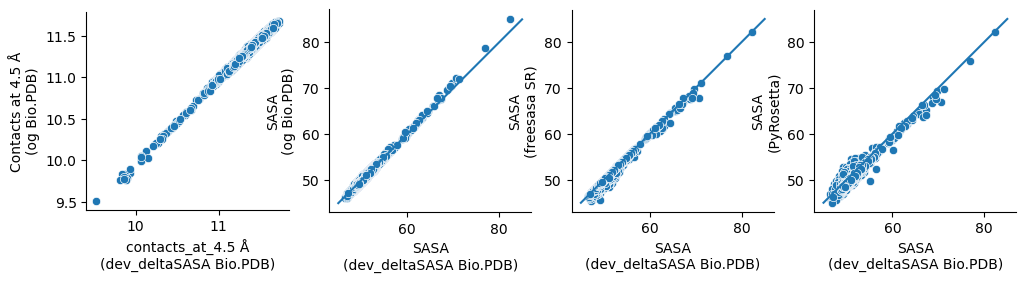

In [67]:
# check that extra_per_res contacts are the same as original metrics
fig = plt.figure(figsize=(12,3))
ax = fig.add_subplot(1,4,1)
sns.scatterplot(x=extra_per_residue_data.groupby('uid').agg({'contacts_at_4.5':'mean'})['contacts_at_4.5'],
                y=python_metrics_df.set_index('uid')['Contacts at 4.5 Å'])
sns.despine()
ax.set_aspect('equal')
ax.set_ylabel('Contacts at 4.5 Å\n(og Bio.PDB)')
ax.set_xlabel('contacts_at_4.5 Å\n(dev_deltaSASA Bio.PDB)')

ax = fig.add_subplot(1,4,2)
sns.scatterplot(x=extra_per_residue_data.groupby('uid').agg({'sasa':'mean'})['sasa'],
                y=python_metrics_df.set_index('uid')['total_sasa_bio'])
sns.despine()
ax.set_aspect('equal')
ax.set_ylabel('SASA\n(og Bio.PDB)')
ax.set_xlabel('SASA\n(dev_deltaSASA Bio.PDB)')
plt.plot((45,85), (45, 85))

ax = fig.add_subplot(1,4,3)
sns.scatterplot(x=extra_per_residue_data.groupby('uid').agg({'sasa':'mean'})['sasa'],
                y=sasas.groupby('uid').agg({'total_sasa_fs':'mean'})['total_sasa_fs'])
sns.despine()
ax.set_aspect('equal')
ax.set_ylabel('SASA\n(freesasa SR)')
ax.set_xlabel('SASA\n(dev_deltaSASA Bio.PDB)')
plt.plot((45,85), (45, 85))

ax = fig.add_subplot(1,4,4)
sns.scatterplot(x=extra_per_residue_data.groupby('uid').agg({'sasa':'mean'})['sasa'],
                y=sasas.groupby('uid').agg({'total_sasa_pr':'mean'})['total_sasa_pr'])
sns.despine()
ax.set_aspect('equal')
ax.set_ylabel('SASA\n(PyRosetta)')
ax.set_xlabel('SASA\n(dev_deltaSASA Bio.PDB)')
plt.plot((45,85), (45, 85))

#### Notes
just for consistency, we are going to only use freeSASA-based SASA estimates, but freeSASA's calculation are very correlated with both bioPython and PyRosetta

In [65]:
# don't need these columns
extra_per_residue_data.drop(['fa_sol', 'fa_atr', 'fa_elec', 'sasa', 'delta_sasa', 'normalized_delta_sasa'], axis=1)

,uid,loc,resname,secondary_structure,contacts_at_4.5,aln_res
0,GB_GCA_001054945.1,1,MET,L,NaN,0.0
1,GB_GCA_001054945.1,2,ARG,E,14.0,1.0
2,GB_GCA_001054945.1,3,LEU,E,16.0,2.0
3,GB_GCA_001054945.1,4,VAL,E,16.0,3.0
4,GB_GCA_001054945.1,5,LEU,E,16.0,4.0
...,...,...,...,...,...,...
1981284,RS_GCF_902813185.1,217,PHE,H,13.0,207.0
1981285,RS_GCF_902813185.1,218,ALA,H,8.0,208.0
1981286,RS_GCF_902813185.1,219,ALA,H,11.0,209.0
1981287,RS_GCF_902813185.1,220,LEU,H,14.0,210.0


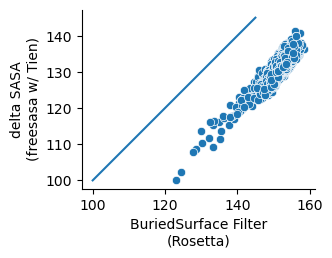

In [76]:
# Are the buried surface estimates correlated?
fig = plt.figure(figsize=(3,3))
ax = fig.add_subplot(1,1,1)
sns.scatterplot(x=ros_bsa.groupby('uid').agg({'bsa_total':'mean'})['bsa_total'],
                y=sasas.groupby('uid').agg({'delta_sasa':'mean'})['delta_sasa'])
sns.despine()
ax.set_aspect('equal')
ax.set_xlabel('BuriedSurface Filter\n(Rosetta)')
ax.set_ylabel('delta SASA\n(freesasa w/ Tien)')
plt.plot((100,145), (100,145))

#### Notes
I think that this is because Rosetta might use the Theoretical maxima, versus I'm using the empirical maxima? and also something with the "Protor radii" vs all atoms for Rosetta. Something to ask Dru.

In [104]:
# First merge SASA and extra residue metrics
sasa_merge = sasas.drop([c for c in sasas.columns if '_pr' in c], axis=1).reset_index().rename(columns={'index':'loc'}).set_index(['uid', 'loc'])

In [105]:
extra_merge = extra_per_residue_data.drop(['fa_sol', 'fa_atr', 'fa_elec', 'sasa', 'delta_sasa', 'normalized_delta_sasa'], axis=1).set_index(['uid', 'loc'])

In [106]:
per_res_data = pd.merge(sasa_merge, extra_merge, left_index=True, right_index=True)

In [107]:
sasa_merge.shape, extra_merge.shape, per_res_data.shape

((1969197, 7), (1981289, 4), (1969197, 11))

In [118]:
per_res_data = per_res_data.drop('resname_y', axis=1).rename(columns={'resname_x':'resname'})

In [120]:
per_res_data.head()

resname  total_sasa_fs  polar_sasa_fs  apolar_sasa_fs  \
uid                loc                                                         
GB_GCA_001054945.1 1       MET      75.287823      19.182296       56.105527   
                   2       ARG      41.924147      41.924147        0.000000   
                   3       LEU       0.000000       0.000000        0.000000   
                   4       VAL       0.135194       0.000000        0.135194   
                   5       LEU       2.898051       2.898051        0.000000   

                                                                      pdb  \
uid                loc                                                      
GB_GCA_001054945.1 1    ./../data/processed_structures/GB_GCA_00105494...   
                   2    ./../data/processed_structures/GB_GCA_00105494...   
                   3    ./../data/processed_structures/GB_GCA_00105494...   
                   4    ./../data/processed_structures/GB_GCA_00105494...   
                   5    ./../data/processed_structures/GB_GCA_00105494...   

                        delta_sasa  norm_delta_sasa secondary_structure  \
uid                loc                                                    
GB_GCA_001054945.1 1    127.712177         0.629124                   L   
                   2    223.075853         0.841796                   E   
                   3    191.000000         1.000000                   E   
                   4    164.864806         0.999181                   E   
                   5    188.101949         0.984827                   E   

                        contacts_at_4.5  aln_res  
uid                loc                            
GB_GCA_001054945.1 1                NaN      0.0  
                   2               14.0      1.0  
                   3               16.0      2.0  
                   4               16.0      3.0  
                   5               16.0      4.0

In [121]:
per_res_data.to_csv('./../data/metric_tables/20260513_per_res_data.tsv.gz', 
                    compression='gzip', sep='\t')

## Finally, compile protein-wide structural metrics dataframe

#### to combine:
```
lid_annotations  
hbond  
per_res_data.group('uid')  
rosetta_df  
```

#### and drop
energy terms from rosetta  

In [10]:
# rosetta_df['genome'] = rosetta_df.index + '.1'
metrics_df = pd.merge(metrics_df, rosetta_df, left_on='uid', right_index=True)

In [11]:
# add temperature
metrics_df['temp'] = metrics_df['uid'].apply(lambda x: float(genome2temp.loc[x]))

## Arranging databases (ugh)

In [12]:
# get GTDB data
gtdb_md = pd.read_csv('/data/mhoffert/genomes/GTDB_r214.1/bac120_metadata.tsv.gz', sep='\t', index_col=0)

/tmp/ipykernel_1611373/3228881117.py:2: DtypeWarning: Columns (61,63,65,74,82,83) have mixed types. Specify dtype option on import or set low_memory=False.
  gtdb_md = pd.read_csv('/data/mhoffert/genomes/GTDB_r214.1/bac120_metadata.tsv.gz', sep='\t', index_col=0)


In [13]:
base_path = '/data/mhoffert/fiererlab/ogt/results/db/'
gtdb_match_data = pd.concat([pd.read_csv(f'{base_path}{db}_gtdb_matching.tsv', sep='\t', index_col=0).assign(db=db) for db in ['melnikov', 'tempura', 'corkey', 'engqvist']])

# gtdb_match_data.head()

tempura_values = gtdb_match_data[gtdb_match_data.db.eq('tempura')]['original_id'].values
engqvist_values = gtdb_match_data[gtdb_match_data.db.eq('engqvist')]['original_id'].values
melnikov_values = gtdb_match_data[gtdb_match_data.db.eq('melnikov')]['original_id'].values

In [14]:
len(gtdb_match_data['original_id'].unique()), gtdb_match_data['original_id'].shape

(31821, (36090,))

In [15]:
gtdb_match_data = pd.merge(gtdb_match_data, gtdb_md[['gtdb_representative']], how='left', left_on='match_accession', right_index=True)

In [16]:
# load databases
gtdb_match_data[gtdb_match_data['db'].eq('tempura')].match_type.value_counts()

match_type
ncbi_taxid    4516
assembly       883
fuzzy          190
silva_ssu       49
Name: count, dtype: int64

In [17]:
# load databases
engqvist = pd.read_csv('/data/mhoffert/fiererlab/ogt/source_data/Engqvist_temperatures.tsv', sep='\t')
engqvist = engqvist[engqvist.domain.eq('Bacteria')]
engqvist['genus'] = engqvist['organism'].apply(lambda x: x.split('_')[0])
engqvist['species'] = engqvist['organism'].apply(lambda x: x.split('_')[1])
print(engqvist.shape)
engqvist.sort_values('taxid').head(8)

corkey = pd.read_csv('/data/mhoffert/fiererlab/ogt/source_data/Corkey_temperatures.csv')
corkey['genus'] = corkey['binomial.name'].apply(lambda x: x.split(' ')[0].lower())
corkey['species'] = corkey['binomial.name'].apply(lambda x: x.split(' ')[1].lower())
corkey.head()

melnikov = pd.read_csv('/data/mhoffert/fiererlab/ogt/source_data/Melnikov_bacteria_nbci_temperatures.csv')
melnikov['org_group'] = melnikov["Organism Groups"].apply(lambda x: x.split(';')[-1])

def reformat_col(old_col):
    new_col = old_col.lower().replace('(', ' ')
    for sub in ['%', ')', '#',]:
        new_col = new_col.replace(sub, '')
    return new_col.replace(' ', '_')

melnikov = melnikov.rename(columns=dict((s, reformat_col(s)) for s in melnikov.columns))
melnikov.head()

tempura = pd.read_csv('/data/mhoffert/fiererlab/ogt/source_data/TEMPURA_temperatures.csv')
tempura.head()

# subset to only bacteria
tempura = tempura[tempura.superkingdom.eq('Bacteria')]
tempura.head()


(13378, 12)


,genus_and_species,taxonomy_id,strain,superkingdom,phylum,class,order,family,genus,assembly_or_accession,Genome_GC,Genome_size,16S_accssion,16S_GC,Tmin,Topt_ave,Topt_low,Topt_high,Tmax,Tmax_Tmin
26,Fervidobacterium pennivorans,93466,Ven 5,Bacteria,Thermotogae,Thermotogae,Thermotogales,Fervidobacteriaceae,Fervidobacterium,GCA_000235405.3,38.9,2.2,NR_074097,61.3,50.0,80.0,NaN,NaN,100.0,50.0
53,Aquifex pyrophilus,2714,Kol5a,Bacteria,Aquificae,Aquificae,Aquificales,Aquificaceae,Aquifex,NaN,47.3,NaN,M83548,64.9,67.0,85.0,NaN,NaN,95.0,28.0
80,Thermosulfurimonas dismutans,999894,S95,Bacteria,Thermodesulfobacteria,Thermodesulfobacteria,Thermodesulfobacteriales,Thermodesulfobacteriaceae,Thermosulfurimonas,NaN,52.0,NaN,JF346116,63.3,50.0,74.0,NaN,NaN,92.0,42.0
93,Thermodesulfobacterium geofontis,1295609,OPF15,Bacteria,Thermodesulfobacteria,Thermodesulfobacteria,Thermodesulfobacteriales,Thermodesulfobacteriaceae,Thermodesulfobacterium,GCA_000215975.1,30.6,1.6,NR_118457,61.9,70.0,83.0,NaN,NaN,90.0,20.0
97,Thermotoga neapolitana,2337,NS-E,Bacteria,Thermotogae,Thermotogae,Thermotogales,Thermotogaceae,Thermotoga,GCA_000018945.1,46.9,1.9,NR_074959,64.0,55.0,80.0,NaN,NaN,90.0,35.0


In [18]:
tempura_series = tempura[['genus_and_species', 'Topt_ave']].assign(database='tempura').rename(columns={'genus_and_species':'original_id', 'Topt_ave':'temp'})

melnikov_series = melnikov[['organism_name', 'temperature']].assign(database='melnikov').rename(columns={'organism_name':'original_id', 'temperature':'temp'})

corkey_series = corkey[['binomial.name', 'T.C']].assign(database='corkey').rename(columns={'binomial.name':'original_id', 'T.C':'temp'})

engqvist_series = engqvist[['organism', 'temperature']].assign(database='engqvist').rename(columns={'organism':'original_id', 'temperature':'temp'})

In [19]:
temp_data = pd.concat([tempura_series, melnikov_series, corkey_series, engqvist_series])
temp_data = temp_data.set_index(['database', 'original_id'])['temp']
temp_data = temp_data.sort_index()
temp_data.head()

database  original_id           
corkey    Acanthamoeba polyphaga    10.000000
          Acanthamoeba polyphaga    15.000000
          Acanthamoeba polyphaga    20.000000
          Acanthamoeba polyphaga    25.000000
          Acarus siro               10.237467
Name: temp, dtype: float64

In [20]:
print(gtdb_match_data.shape)
gtdb_match_data.head()

(36090, 10)


,original_id,orginal_genus,original_species,match_ratio,match_accession,match_genus,match_species,match_type,db,gtdb_representative
0,Polaribacter irgensii 23-P,Polaribacter,irgensii,NaN,RS_GCF_000153225.1,polaribacter,irgensii,assembly,melnikov,t
1,Polaribacter filamentus,Polaribacter,filamentus,NaN,RS_GCF_002943715.1,polaribacter,filamentus,assembly,melnikov,t
2,Octadecabacter antarcticus 307,Octadecabacter,antarcticus,NaN,RS_GCF_000155675.2,octadecabacter,antarcticus,assembly,melnikov,t
3,Octadecabacter arcticus 238,Octadecabacter,arcticus,NaN,RS_GCF_000155735.2,octadecabacter,arcticus,assembly,melnikov,t
4,Shewanella violacea DSS12,Shewanella,violacea,NaN,RS_GCF_000091325.1,shewanella,violacea,assembly,melnikov,t


In [21]:
gtdb_match_data['match_type'].value_counts()

match_type
assembly      15230
ncbi_taxid    14637
fuzzy           284
silva_ssu        67
Name: count, dtype: int64

In [22]:
gtdb_match_data['match_type'] = gtdb_match_data['match_type'].fillna('fuzzy')

In [23]:
grouped = gtdb_match_data.groupby(['match_accession', 'db', 'match_type']).apply(lambda x: x['original_id'].unique())

In [24]:
cols = ['gtdb_accession', 'db', 'match_type', 'original_id', 'temp']
new_match_data = pd.DataFrame(columns=cols)
idx = pd.IndexSlice
i = 0
errors = []
for index, row in grouped.items():
    if i % 100 == 0:
        display(i)
        clear_output(wait=True)
    for oid in row:
        try:
            new_match_data.loc[i, :] = pd.Series(index=cols, data=[index[0], 
                                                               index[1], 
                                                               index[2],
                                                               oid,
                                                               float(temp_data.loc[idx[index[1], oid]].values[0])])
            i += 1
        except KeyError:
            errors.append((index, row))

30500

In [25]:
len(errors)

4

In [26]:
new_match_data.head()

,gtdb_accession,db,match_type,original_id,temp
0,GB_GCA_000010565.1,corkey,fuzzy,Pelotomaculum thermopropionicum,45.025689
1,GB_GCA_000010565.1,engqvist,ncbi_taxid,pelotomaculum_thermopropionicum,55.0
2,GB_GCA_000010565.1,tempura,ncbi_taxid,Pelotomaculum thermopropionicum,55.0
3,GB_GCA_000011445.1,engqvist,ncbi_taxid,mycoplasma_mycoides,37.0
4,GB_GCA_000012145.1,melnikov,assembly,Rickettsia felis,NaN


In [27]:
new_match_data['db'].value_counts()

db
melnikov    14388
engqvist    10192
tempura      5634
corkey        377
Name: count, dtype: int64

In [28]:
new_match_data.groupby('gtdb_accession').agg({'temp':'mean'})

,temp
gtdb_accession,
GB_GCA_000010565.1,51.67523
GB_GCA_000011445.1,37.0
GB_GCA_000012145.1,NaN
GB_GCA_000014225.1,26.5
GB_GCA_000016765.1,30.0
...,...
RS_GCF_923081025.1,30.0
RS_GCF_928381505.1,32.5
RS_GCF_937425535.1,31.25


Text(0.5, 0, 'All dataset mean')

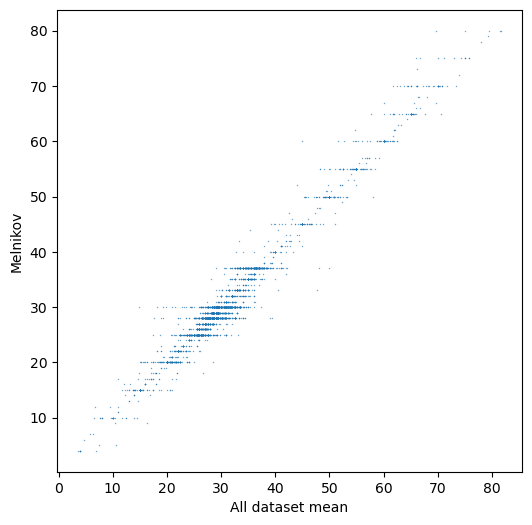

In [29]:
fig, ax = plt.subplots(figsize=(6,6))
sns.scatterplot(y=metrics_df.set_index('uid')['temp'], x=new_match_data.groupby('gtdb_accession').agg({'temp':'mean'})['temp'],
               linewidth=0, alpha=0.65, s=1)
ax.set_ylabel('Melnikov')
ax.set_xlabel('All dataset mean')

In [38]:
corr_data = new_match_data.groupby(['gtdb_accession', 'db']).agg({'temp':'mean', })['temp'].unstack()

<Axes: xlabel='count', ylabel='Count'>

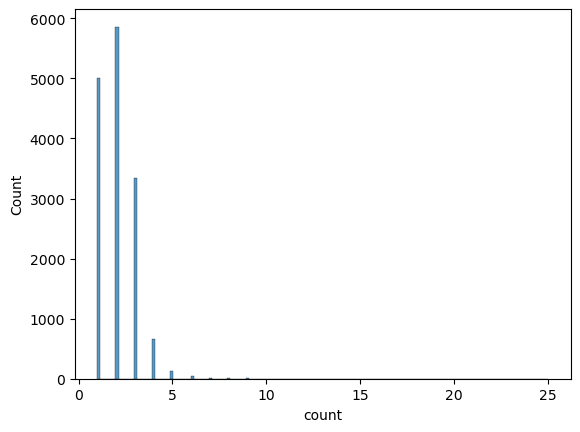

In [41]:
sns.histplot(new_match_data['gtdb_accession'].value_counts())

In [55]:
new_match_data[new_match_data['db'].isin(['corkey', 'melnikov'])].sort_values('gtdb_accession')

,gtdb_accession,db,match_type,original_id,temp
0,GB_GCA_000010565.1,corkey,fuzzy,Pelotomaculum thermopropionicum,45.025689
4,GB_GCA_000012145.1,melnikov,assembly,Rickettsia felis,NaN
5,GB_GCA_000014225.1,melnikov,assembly,Pseudoalteromonas atlantica T6c,23.0
8,GB_GCA_000016765.1,melnikov,assembly,Sphingomonas wittichii RW1,30.0
10,GB_GCA_000017245.1,melnikov,assembly,Actinobacillus succinogenes,30.0
...,...,...,...,...,...
30566,RS_GCF_910593725.1,melnikov,assembly,Candidatus Vallotia tarda,NaN
30567,RS_GCF_910593845.1,melnikov,assembly,Paenibacillus solanacearum,30.0
30574,RS_GCF_914271545.1,melnikov,assembly,Cupriavidus respiraculi,32.0
30587,RS_GCF_937425535.1,melnikov,assembly,Rhodovastum atsumiense,30.0


In [52]:
corr_data[['corkey', 'melnikov']].dropna()

db,corkey,melnikov
gtdb_accession,,
GB_GCA_001048675.1,15.133736,32.0
GB_GCA_001610955.1,44.928826,55.0
GB_GCA_003148465.1,56.5,37.0
GB_GCA_003722315.1,37.300251,70.0
GB_GCA_018853935.1,19.963736,28.0
...,...,...
RS_GCF_900182585.1,45.228275,70.0
RS_GCF_900215245.1,0.0,30.0
RS_GCF_900215515.1,50.095435,70.0


Text(0.5, 0, 'Corkey')

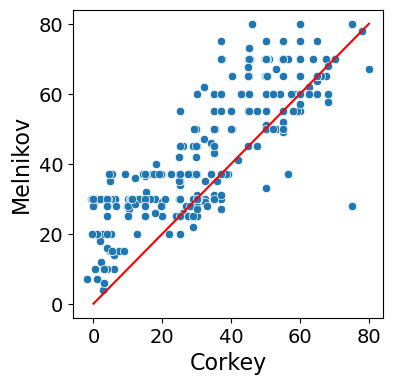

In [56]:
fig, ax = plt.subplots(figsize=(4,4))
sns.scatterplot(data=corr_data, x='corkey', y='melnikov')
plt.plot((0, 80), (0, 80), color='r')
plt.tick_params(labelsize=14)
ax.set_ylabel('Melnikov', fontsize=16)
ax.set_xlabel('Corkey', fontsize=16)

In [30]:
new_temps = new_match_data.groupby('gtdb_accession').agg({'temp':'mean'})['temp']

Text(0.5, 0, 'SASA')

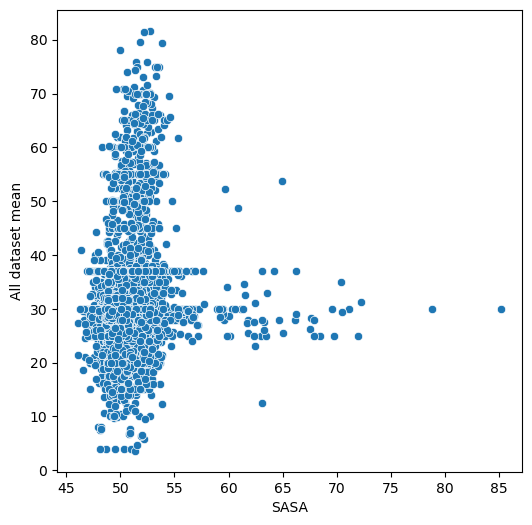

In [31]:
# new correlations
fig, ax = plt.subplots(figsize=(6,6))
sns.scatterplot(x=metrics_df.set_index('uid')['SASA'], y=new_temps)
ax.set_ylabel('All dataset mean')
ax.set_xlabel('SASA')

#### Notes
It does look like using the new temps cleans up some of the discretization

In [35]:
metrics_df['mean_temp'] = metrics_df['uid'].apply(lambda x: new_temps.loc[x] if x in new_temps.index else metrics_df.loc[x, 'temp'])

In [51]:
new_match_data[new_match_data['db'].eq('corkey')].groupby('gtdb_accession').agg({'temp':'mean'})['temp'].to_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/metric_tables/20240410_corkey_save.tsv', sep='\t')

# Saving

In [36]:
secondary_structure.to_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/metric_tables/20240327_ss_save.tsv', sep='\t')

In [37]:
metrics_df.to_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/metric_tables/20240327_metrics_df_save.tsv', sep='\t', index=False)